# 17.2.1 阈值最小二乘与独立 Lorenz 轨迹

## 学习目标与先修知识

手写顺序阈值最小二乘（sequential thresholded least squares，STLSQ），分别检查稀疏项和未参与拟合的初态。

先修：17.1.1 Lorenz 原文条件；最小二乘。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

若训练导数（derivative）几乎完全拟合，如何知道阈值筛项有用？独立初态会不会立即失配？

In [1]:
import itertools
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先计算一个可手算的数值，再提出本节需要核验的主张。

In [2]:
X=np.array([[1.,0.],[1.,1.],[1.,2.],[1.,3.]]);print("最小二乘：",np.linalg.lstsq(X,[1.,3.,5.,7.],rcond=None)[0])

最小二乘： [1. 2.]


## 模型假设

训练轨迹（trajectory）从原文初态 (-8,7,27) 出发，课程取前 4 时间单位、每 0.01 T 一点、二次字典。测试初态 (1,1,1) 在拟合前固定；测试轨迹不参与字典系数求解或阈值选择。阈值 0.1、十次重拟合在运行前固定。导数由生成方程给出，是无噪声上限实验。

## 数学解释与推导

先解 $\hat\Xi=\arg\min_\Xi\|\Theta\Xi-\dot X\|_F^2$；每次将 $|\hat\Xi_{ij}|<\lambda$ 的项置零，然后对每个状态（state）导数的保留列重新做最小二乘。稀疏模式应与 $(-10x+10y,28x-y-xz,xy-8z/3)$ 比较。另以新初态推进发现方程，比较独立轨迹的短窗口误差。

## 核心实现

以下短函数展示方程、数值步骤和可修改的计算顺序。

In [3]:
def lorenz_rhs(state, sigma=10., rho=28., beta=8./3.):
    x,y,z=np.asarray(state,dtype=float)
    return np.array([sigma*(y-x),x*(rho-z)-y,x*y-beta*z],dtype=float)


def rk4_path(rhs, initial, h, steps):
    state=np.asarray(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        k1=np.asarray(rhs(state));k2=np.asarray(rhs(state+h*k1/2))
        k3=np.asarray(rhs(state+h*k2/2));k4=np.asarray(rhs(state+h*k3))
        state=state+h*(k1+2*k2+2*k3+k4)/6
        rows.append(state.copy())
    return np.asarray(rows)


def polynomial_library(states, degree=2):
    states=np.atleast_2d(np.asarray(states,dtype=float))
    terms=[()]
    for order in range(1,degree+1):
        terms.extend(itertools.combinations_with_replacement(range(states.shape[1]),order))
    matrix=np.column_stack([np.prod(states[:,indices],axis=1) if indices else np.ones(len(states)) for indices in terms])
    labels=['1' if not indices else '*'.join('xyz'[i] if i<3 else f'x{i}' for i in indices) for indices in terms]
    return matrix,labels


def stlsq(features, derivatives, threshold=.1, iterations=10):
    """Sequential thresholded least squares with an explicit refit per target."""
    X=np.asarray(features,dtype=float);Y=np.atleast_2d(np.asarray(derivatives,dtype=float))
    if Y.shape[0]!=X.shape[0]:Y=Y.T
    coefficients=np.linalg.lstsq(X,Y,rcond=None)[0]
    for _ in range(iterations):
        keep=np.abs(coefficients)>=threshold
        updated=np.zeros_like(coefficients)
        for column in range(Y.shape[1]):
            if keep[:,column].any():
                updated[keep[:,column],column]=np.linalg.lstsq(X[:,keep[:,column]],Y[:,column],rcond=None)[0]
        coefficients=updated
    return coefficients

## 对照实验

先用训练初态估计方程系数，再从 [1,1,1] 出发比较已知方程与发现方程的短时轨迹。

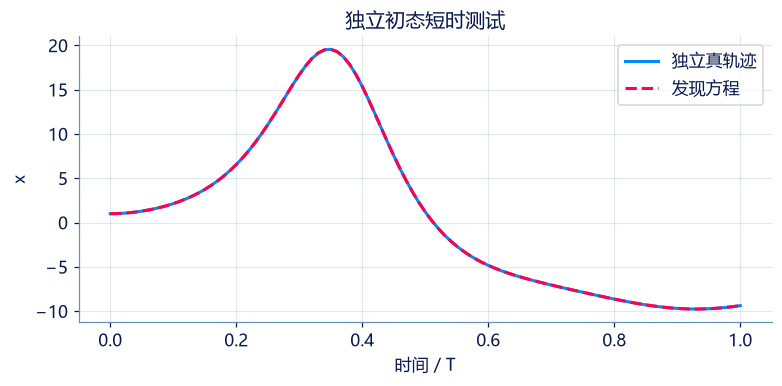

非零项： [('x', [-10.0, 28.0, 0.0]), ('y', [10.0, -1.0, 0.0]), ('z', [0.0, 0.0, -2.667]), ('x*y', [0.0, 0.0, 1.0]), ('x*z', [0.0, -1.0, 0.0])]
测试 RMSE： 3.3037910155009733e-13


In [4]:
train=rk4_path(lorenz_rhs,[-8.,7.,27.],.01,400);Phi,labels=polynomial_library(train,2);dX=np.asarray([lorenz_rhs(row) for row in train]);Xi=stlsq(Phi,dX,.1,10)
truth=rk4_path(lorenz_rhs,[1.,1.,1.],.01,100);identified=rk4_path(lambda s:polynomial_library(s,2)[0][0]@Xi,[1.,1.,1.],.01,100)
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(np.arange(101)*.01,truth[:,0],label="独立真轨迹",color=BLUE);ax.plot(np.arange(101)*.01,identified[:,0],"--",label="发现方程",color=PINK);ax.set(xlabel="时间 / T",ylabel="x",title="独立初态短时测试");ax.legend();ax.grid(alpha=.2);plt.show()
print("非零项：",[(label,np.round(row,3).tolist()) for label,row in zip(labels,Xi) if np.max(abs(row))>.05]);print("测试 RMSE：",np.sqrt(np.mean((truth-identified)**2)))

## 结果解释

发现项、系数和测试误差是三个不同的核验。这里用精确导数隔离字典筛选的影响；含噪求导的作用在下一章另作对照。

### 独立核对

把拟合系数与已知 Lorenz 各项逐一比较，再计算独立初态上的轨迹误差。

In [5]:
expected=np.zeros_like(Xi);lookup={name:i for i,name in enumerate(labels)}
for name,column,value in [("x",0,-10),("y",0,10),("x",1,28),("y",1,-1),("x*z",1,-1),("x*y",2,1),("z",2,-8/3)]:expected[lookup[name],column]=value
np.testing.assert_allclose(Xi,expected,atol=.15);assert np.sqrt(np.mean((truth-identified)**2))<.1
print("原方程系数与独立初态短窗核验通过。")

原方程系数与独立初态短窗核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/17-02-%E5%A4%8D%E7%8E%B0%E5%8D%8F%E8%AE%AE%E4%B8%8E%E5%85%AC%E5%B9%B3%E5%9F%BA%E7%BA%BF/explore/)。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：公平轨迹划分

如何检验发现方程在新初态上是否仍有效？

- **A.** 用测试轨迹（trajectory）选阈值
- **B.** 训练前固定并隔离另一初态轨迹
- **C.** 只看训练残差（residual）
- **D.** 挑一条最好看的测试曲线

[作答：公平轨迹划分](http://127.0.0.1:8000/chapters/17-02-%E5%A4%8D%E7%8E%B0%E5%8D%8F%E8%AE%AE%E4%B8%8E%E5%85%AC%E5%B9%B3%E5%9F%BA%E7%BA%BF/practice/?question=p17-c2s1-choice1)

### 第 2 题 · 单项选择题：阈值重拟合

顺序阈值最小二乘（sequential thresholded least squares，STLSQ）每轮为何重拟合？

- **A.** 让被删项自动恢复
- **B.** 让保留项在当前支持集上重新估计
- **C.** 改变训练集（training set）初态
- **D.** 使所有系数相等

[作答：阈值重拟合](http://127.0.0.1:8000/chapters/17-02-%E5%A4%8D%E7%8E%B0%E5%8D%8F%E8%AE%AE%E4%B8%8E%E5%85%AC%E5%B9%B3%E5%9F%BA%E7%BA%BF/practice/?question=p17-c2s1-choice2)

### 第 3 题 · Python 计算题：划分交叉审计

若训练导数（derivative）几乎完全拟合，如何知道阈值筛项有用？独立初态会不会立即失配？本题计算“划分交叉审计”：求三个集合两两交集的并集并排序；没有交叉时返回 [True,[]]。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    train_ids: list[int],
    validation_ids: list[int],
    test_ids: list[int],
) -> list:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `train_ids` | `list[int]` | 训练轨迹（trajectory）编号。 | 轨迹 |
| `validation_ids` | `list[int]` | 验证轨迹编号。 | 轨迹 |
| `test_ids` | `list[int]` | 独立测试轨迹编号。 | 轨迹 |

**返回值**

直接返回 result（list）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `result` | `list` | 首项为无交叉标志，第二项为升序重复编号。 | 混合 |

**计算规则**

求三个集合两两交集的并集并排序；没有交叉时返回 [True,[]]。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵（matrix）维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| train_ids | 训练轨迹（trajectory）编号。 | [1, 2] | 轨迹 |
| validation_ids | 验证轨迹编号。 | [3] | 轨迹 |
| test_ids | 独立测试轨迹编号。 | [2, 4] | 轨迹 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
train_ids = [1, 2]
validation_ids = [3]
test_ids = [2, 4]

result = solve(train_ids, validation_ids, test_ids)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| result | 首项为无交叉标志，第二项为升序重复编号。 | [False, [2]] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [False, [2]]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；求三个集合两两交集的并集并排序；没有交叉时返回 [True,[]]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：划分交叉审计](http://127.0.0.1:8000/chapters/17-02-%E5%A4%8D%E7%8E%B0%E5%8D%8F%E8%AE%AE%E4%B8%8E%E5%85%AC%E5%B9%B3%E5%9F%BA%E7%BA%BF/practice/?question=p17-disjoint-trajectories)

### 第 4 题 · Python 计算题：顺序阈值重拟合

若训练导数（derivative）几乎完全拟合，如何知道阈值筛项有用？独立初态会不会立即失配？本题计算“顺序阈值重拟合”：先最小二乘，再迭代将 |系数|<threshold 的位置清零；各状态（state）列只在保留列上重拟合。请按下方具名参数（parameter）和返回结构实现 solve。

**函数与代码模板**

```python
def solve(
    features: list[list[float]],
    derivatives: list[list[float]],
    threshold: float,
    iterations: int,
) -> list[list[float]]:
    # 按题给公式计算，保留全部返回项。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `features` | `list[list[float]]` | 样本×候选项设计矩阵（design matrix）。 | 混合 |
| `derivatives` | `list[list[float]]` | 样本×状态导数矩阵（matrix）。 | 状态/T |
| `threshold` | `float` | 原系数量纲（dimension）下的绝对值阈值。 | 系数 |
| `iterations` | `int` | 顺序筛除并重拟合次数。 | 轮 |

**返回值**

直接返回 coefficients（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `coefficients` | `list[list[float]]` | 候选项×状态的系数矩阵。 | 混合 |

**计算规则**

先最小二乘，再迭代将 |系数|<threshold 的位置清零；各状态列只在保留列上重拟合。

**约束与边界**

- 全部数值有限；列表规模不超过 100；按题给顺序返回。
- 输入（input）满足模型（model）和矩阵维度要求；不在函数内抽样或读取外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| features | 样本×候选项设计矩阵（design matrix）。 | [[1.0, 0.0], [1.0, 1.0], [1.0, 2.0]] | 混合 |
| derivatives | 样本×状态导数矩阵（matrix）。 | [[1.0], [3.0], [5.0]] | 状态/T |
| threshold | 原系数量纲（dimension）下的绝对值阈值。 | 0.1 | 系数 |
| iterations | 顺序筛除并重拟合次数。 | 2 | 轮 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
features = [[1.0, 0.0], [1.0, 1.0], [1.0, 2.0]]
derivatives = [[1.0], [3.0], [5.0]]
threshold = 0.1
iterations = 2

result = solve(features, derivatives, threshold, iterations)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| coefficients | 候选项×状态的系数矩阵。 | [[0.9999999999999997], [1.9999999999999998]] | 混合 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.9999999999999997],
                   [1.9999999999999998]]
```

**样例解释**

输入样例代入计算规则后得到所示输出（output）；先最小二乘，再迭代将 |系数|<threshold 的位置清零；各状态列只在保留列上重拟合。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：顺序阈值重拟合](http://127.0.0.1:8000/chapters/17-02-%E5%A4%8D%E7%8E%B0%E5%8D%8F%E8%AE%AE%E4%B8%8E%E5%85%AC%E5%B9%B3%E5%9F%BA%E7%BA%BF/practice/?question=p17-sparse-refit)

**原始参考**

[Brunton、Proctor 与 Kutz，arXiv:1509.03580v1](https://arxiv.org/abs/1509.03580v1)